Regularization in machine learning is a technique used to prevent models from becoming overly complex and fitting the training data too closely. The goal of regularization is to improve a model's ability to generalize to new, unseen data by reducing the risk of overfitting.
Overfitting occurs when a model learns the noise and random fluctuations in the training data rather than the underlying patterns that are consistent across different datasets. This can lead to poor performance on new data because the model becomes too specialized to the training set.
Regularization methods add an additional term to the model's objective function (usually the loss function) during training. This extra term discourages the model from having very large parameter values. There are two common types of regularization used in machine learning:

1. Lasso Regularization (L1 Regularization):
The Lasso regularization adds a penalty term based on the sum of the absolute values of the coefficients. Lasso has the unique property of driving some coefficients exactly to zero, effectively performing feature selection.
Regularized Loss = Loss + α * Σ|coefficient_i|

Where:

Loss: The original loss function, often the mean squared error (MSE) for regression tasks. α (alpha): The regularization parameter controlling the strength of the regularization. Σ|coefficient_i|: The sum of absolute values of coefficients. The Lasso Regularized equation for linear regression: y = β0 + β1x1 + β2x2 + ... + βn*xn + α * Σ|coefficient_i|


2. Ridge Regularization (L2 Regularization):
The Ridge regularization adds a penalty term based on the sum of the squared values of the coefficients. The goal is to shrink the coefficients towards zero while still allowing them to be non-zero.
Regularized Loss = Loss + α * Σ(coefficient_i^2)




 Where:

Loss: The original loss function, often the mean squared error (MSE) for regression tasks. α (alpha): The regularization parameter controlling the strength of the regularization. Σ(coefficient_i^2): The sum of squared coefficients. The Ridge Regularized equation for linear regression: y = β0 + β1x1 + β2x2 + ... + βn*xn + α * Σ(coefficient_i^2)

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv("/content/Advertising.csv")

Text(0.5, 1.0, 'Newspaper Spend')

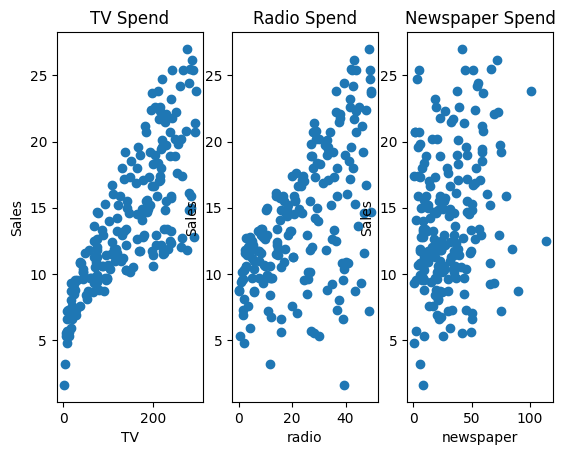

In [5]:
fig, axis = plt.subplots(nrows = 1, ncols = 3)

axis[0].plot(df["TV"], df["sales"], "o")
axis[1].plot(df["radio"], df["sales"], "o")
axis[2].plot(df["newspaper"], df["sales"], "o")

axis[0].set_xlabel("TV")
axis[0].set_ylabel("Sales")
axis[0].set_title("TV Spend")

axis[1].set_xlabel("radio")
axis[1].set_ylabel("Sales")
axis[1].set_title("Radio Spend")

axis[2].set_xlabel("newspaper")
axis[2].set_ylabel("Sales")
axis[2].set_title("Newspaper Spend")

In [6]:
x = df.drop("sales", axis = 1)
y = df["sales"]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, random_state = 0)

In [8]:
scalar = StandardScaler()

x_train_scaled = scalar.fit_transform(x_train)
x_test_scaled = scalar.fit_transform(x_test)

In [9]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

#Lasso Model
ls = Lasso(alpha = 1.0)
ls.fit(x_train_scaled, y_train)

#Ridge Model
rs = Ridge(alpha = 1.0)
rs.fit(x_train_scaled, y_train)

Ridge()

In [10]:
y_pred_lr = lr.predict(x_test_scaled)
y_pred_ls = ls.predict(x_test_scaled)
y_pred_rs = rs.predict(x_test_scaled)

In [11]:
print("Linear Regression mse:", mean_squared_error(y_test, y_pred_lr))
print("Lasso mse:", mean_squared_error(y_test, y_pred_ls))
print("Ridge mse:", mean_squared_error(y_test, y_pred_rs))
print("\n")
print("Linear Regression accuracy:", (r2_score(y_test, y_pred_lr)) * 100, "%")
print("Lasso accuracy:", (r2_score(y_test, y_pred_ls)) * 100, "%")
print("Ridgen accuracy:", (r2_score(y_test, y_pred_rs)) * 100, "%")

Linear Regression mse: 5.553476360437547
Lasso mse: 6.789572109523294
Ridge mse: 5.551429307683992


Linear Regression accuracy: 79.6753209044339 %
Lasso accuracy: 75.15144292225018 %
Ridgen accuracy: 79.68281273254433 %


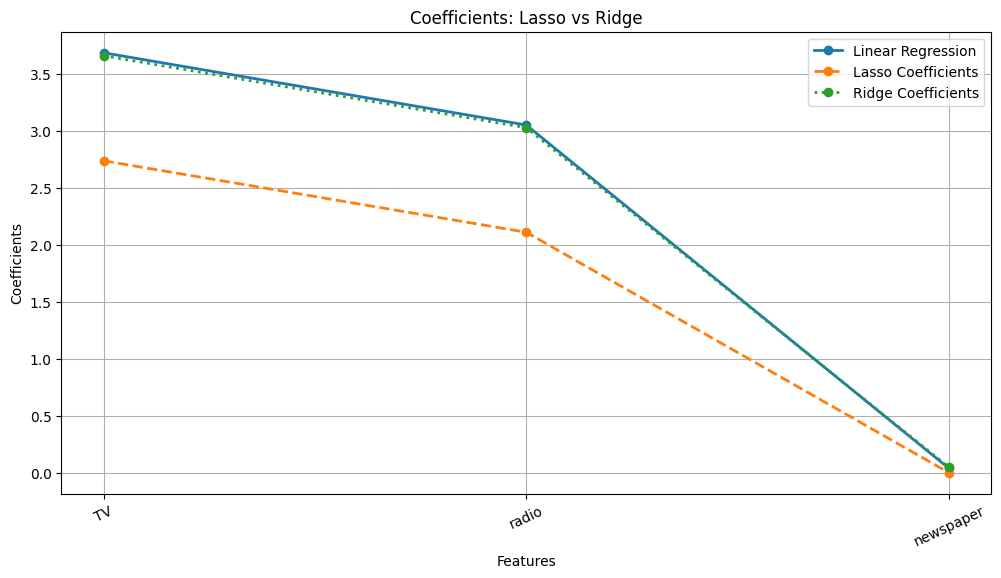

In [13]:
plt.figure(figsize = (12, 6))

plt.plot(x.columns, lr.coef_, marker = "o", label = "Linear Regression", linestyle = "-", linewidth = 2)
plt.plot(x.columns, ls.coef_, marker = "o", label = "Lasso Coefficients", linestyle = "--", linewidth = 2)
plt.plot(x.columns, rs.coef_, marker = "o", label = "Ridge Coefficients", linestyle = ":", linewidth = 2)

plt.xticks(rotation = 25)

plt.xlabel("Features")
plt.ylabel("Coefficients")
plt.title("Coefficients: Lasso vs Ridge")

plt.legend()
plt.grid()

plt.show()